# Transition Kernel PDF representation

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
import pandas as pd
import statsmodels.api as sm
import scipy.special
from arch import arch_model
from scipy.stats import median_abs_deviation
from scipy.optimize import minimize
from scipy.integrate import trapezoid

In [2]:
# models

def f_OU(sigma, sigma_0, m, k, alpha,  t, t_0):
    """ Transition kernel for OU model.
        Variables: 
        sigma = current volatility
        sigma_0 = previous step volatility

        Parameters:
        m = reverting mean
        k = strength of the noise
        alpha = speed of mean reversion
        t = time at which we want to evaluate the pdf
        t=0 = previous time step """
    
    phi = np.exp(- alpha*(t-t_0))
    f = (1/np.sqrt(2*np.pi*k**2/(2*alpha)*(1-phi**2)))*np.exp(-((sigma-m - phi*(sigma_0-m))**2)/(2*k**2/(2*alpha)*(1-phi**2)))

    return f

def f_expOU(sigma, sigma_0, m, k, alpha, t, t_0):
    """ Transition kernel for expOU model.
        Variables: 
        sigma = current volatility
        sigma_0 = previous step volatility

        Parameters:
        m = reverting mean
        k = strength of the noise
        alpha = speed of mean reversion
        t = time at which we want to evaluate the pdf
        t=0 = previous time step """
    
    phi = np.exp(- alpha*(t-t_0))
    f = (1/(sigma*(np.sqrt((2*np.pi*k**2)/(2*alpha)*(1-phi**2)))))*np.exp(-((np.log(sigma)-m - phi*(np.log(sigma_0)-m))**2)/(2*k**2/(2*alpha)*(1-phi**2)))

    return f

def f_heston(sigma, sigma_0, kappa, theta, delta, t=1, t_0=0):
    """Transition kernel for Heston model.
       Variables:
       sigma = current volatility
       sigma_0 = previous step volatility
       Parameters:
       kappa = speed of mean reversion
       theta = long-term mean volatility
       delta = volatility of volatility
       t = time at which we want to evaluate the pdf
       t_0 = previous time step (default 0)
    """
    dt = t - t_0
    c   = (delta**2 * (1 - np.exp(-kappa*dt))) / (4*kappa)
    nu  = (2*kappa*theta) / (delta**2)

    z = sigma * sigma_0 * np.exp(-kappa*dt/2) / c

    # Use ive for numerical stability (ive = exp(-z)*I_nu)
    # so we add z back in the exponent manually
    f = (sigma / c) \
        * np.exp(-(sigma**2 + sigma_0**2 * np.exp(-kappa*dt)) / (2*c) + z) \
        * (sigma / (sigma_0 * np.exp(-kappa*dt/2))) ** (nu - 1) \
        * scipy.special.ive(nu - 1, z)

    return np.where(np.isfinite(f), f, 0.0)

def f_arch(sigma, sigma_0, alpha_0, alpha_1):
    """ Transition kernel for ARCH model.
        Variables:
        sigma = current volatility
        sigma_0 = previous step volatility

        Parameters:
        alpha_0 = constant term
        alpha_1 = weight of previous returns
    """
    f=np.zeros_like(sigma)
    mask = sigma**2 > alpha_0
    f[mask]= ((2*sigma[mask])/(np.sqrt(2*np.pi*alpha_1*sigma_0**2 *(sigma[mask]**2 - alpha_0))))*np.exp(-(sigma[mask]**2-alpha_0)/(2*alpha_1*sigma_0**2))

    return f

def f_garch(sigma, sigma_0, omega, alpha, beta):
    """ Transition kernel for GARCH model.
        Variables:
        sigma = current volatility
        sigma_0 = previous step volatility

        Parameters:
        omega = constant term
        alpha = weight of previous returns
        beta = weight of previous volatility
    """
    f=np.zeros_like(sigma)
    mask = sigma**2 > omega + beta*sigma_0**2
    f[mask]= ((2*sigma[mask])/(np.sqrt(2*np.pi*alpha*sigma_0**2 *(sigma[mask]**2 - omega - beta*sigma_0**2) )))*np.exp(-(sigma[mask]**2-omega-beta*sigma_0**2)/(2*(alpha*sigma_0**2)))

    return f

### Data loading and parameter estimation

OLS estimates parameters by minimizing the sum of squared residuals:

$$
\min_{\beta} \sum_{i=1}^n (y_i - x_i^T \beta)^2
$$

- $y_i$: observed value  
- $x_i^T \beta$: predicted value  

Closed-form solution:

$$
\hat{\beta} = (X^T X)^{-1} X^T y
$$


In [3]:
# ==================== Data ====================
ticker = "^DJI"
data = yf.download("^DJI", start="2024-01-01", end="2025-01-01")
prices = data["Close"].values.flatten()

# For a better adjustment of the models, we use realized volatility instead of squared returns, as it is a more accurate measure of the underlying volatility process. 
# We compute it using a rolling window of 10 days, which is a common choice in the literature.
# Returns and empirical volatility
returns = np.diff(np.log(prices))  # daily log returns
returns_annualized = returns * np.sqrt(252)  # annualize the returns
returns=returns_annualized

window = 12  # 10-day rolling volatility
sigma_real = np.array([np.std(returns[i-window+1:i+1]) for i in range(window-1, len(returns))]) #already annualized in returns

# align returns with sigma_real
returns = returns[window-1:]

#OU parameters
X = sigma_real[:-1]
Y = sigma_real[1:]
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()

c = model.params[0]
phi = np.clip(model.params[1], 0.0001, 0.9999) # to ensure stationarity
alpha_ou = -np.log(phi)
m_ou = c/(1-phi)
k_ou = np.sqrt(2*alpha_ou) * np.std(model.resid) / np.sqrt(1-phi**2)

#expOU parameters
Ylog = np.log(sigma_real + 1e-8)
X = Ylog[:-1]
Z = Ylog[1:]
X = sm.add_constant(X)
model = sm.OLS(Z, X).fit()

c = model.params[0]
phi = np.clip(model.params[1], 0.0001, 0.9999) # to ensure stationarity
alpha_expou = -np.log(phi)
m_expou = c/(1-phi)
k_expou = np.sqrt(2*alpha_expou) * np.std(model.resid) / np.sqrt(1-phi**2)

# Heston parameters:

v_real = sigma_real**2
dv = v_real[1:] - v_real[:-1]  # Differences
X = v_real[:-1]

# Manual OLS
X_mean = np.mean(X)
dv_mean = np.mean(dv)
b = np.sum((X - X_mean) * (dv - dv_mean)) / np.sum((X - X_mean)**2)
a = dv_mean - b * X_mean

if b < 0:  # Mean reverting (should be negative)
    kappa = -b
    theta = a / kappa
    resid = dv - (a + b * X)
    delta = np.std(resid) / np.sqrt(np.mean(v_real))
else:
    print('Warning: No mean reversion detected!')



# ARCH(1) parameters
arch_model_fit = arch_model(returns, vol='ARCH', p=1, rescale=False).fit(disp='off')
alpha0 = arch_model_fit.params['omega']
alpha1 = arch_model_fit.params['alpha[1]']

# GARCH(1,1) parameters
garch_model_fit = arch_model(returns, vol='GARCH', p=1, q=1, rescale=False).fit(disp='off')
omega = garch_model_fit.params['omega']
alpha = garch_model_fit.params['alpha[1]']
beta = garch_model_fit.params['beta[1]']


print("OU parameters:")
print("alpha:", alpha_ou)
print("m:", m_ou)
print("k:", k_ou)
print("")
print("expOU parameters:")
print("alpha:", alpha_expou)
print("m:", m_expou)
print("k:", k_expou)
print("")
print("Heston parameters:")
print("kappa:", kappa)
print("theta:", theta)
print("delta:", delta)
print("")
#multiplied by 100 to match the scale of returns:
print("ARCH(1) parameters:") 
print("alpha0:", alpha0)
print("alpha1:", alpha1)
print("")
print("GARCH(1,1) parameters:")
print("omega:", omega)
print("alpha:", alpha)
print("beta:", beta)



[*********************100%***********************]  1 of 1 completed

OU parameters:
alpha: 0.07455907966509126
m: 0.10736641735604431
k: 0.013553847686349632

expOU parameters:
alpha: 0.0920326640321766
m: -2.290654827601607
k: 0.13783494079942532

Heston parameters:
kappa: 0.06777900386210768
theta: 0.012837395462828523
delta: 0.028566867413585325

ARCH(1) parameters:
alpha0: 0.012022297006866864
alpha1: 0.1060939726658183

GARCH(1,1) parameters:
omega: 0.004466015050388637
alpha: 0.11195162428663853
beta: 0.5591870781172799


### Volatility Behaviour

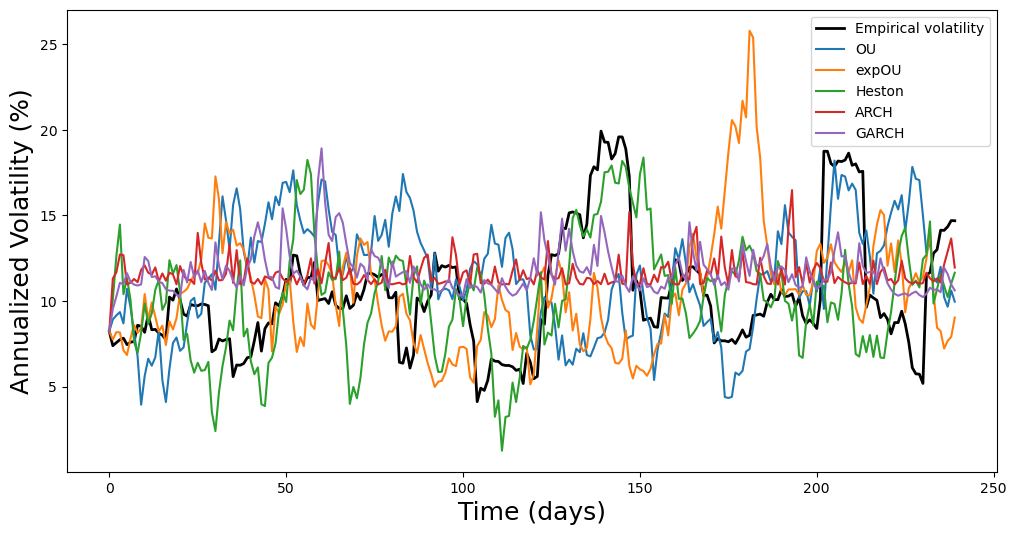

In [4]:
#OU
Dt=1
sigma_ou = np.zeros(len(sigma_real))
sigma_ou[0] = sigma_real[0]
phi = np.exp(-alpha_ou)
noise_std = np.sqrt(k_ou**2/(2*alpha_ou)*(1-phi**2)) #noise is a gaussian with a strd. dev. 
for t in range(1,len(sigma_real)):
    noise = noise_std*np.random.randn() 
    sigma_ou[t] = m_ou + phi*(sigma_ou[t-1]-m_ou) + noise
    #sigma_ou[t] = (sigma_ou[t-1] + alpha_ou*(m_ou - sigma_ou[t-1])*Dt + noise)
    

#expOU
#sigma_stat_expou = np.exp(m_expou + k_expou**2 / (4 * alpha_expou)) # This would start the model at the stationary value
sigma_expou = np.zeros(len(sigma_real))
sigma_expou[0] = sigma_real[0] # start at the empirical volatility
Y = np.log(sigma_expou[0]) # start at the stationary value
phi = np.exp(-alpha_expou)
noise_std = np.sqrt(k_expou**2/(2*alpha_expou)*(1-phi**2))
for t in range(1,len(sigma_real)):
    noise = noise_std*np.random.randn()
    Y = m_expou + phi*(Y-m_expou) + noise
    sigma_expou[t] = np.exp(Y)

# Heston / CIR simulation
sigma_heston = np.zeros(len(sigma_real))
sigma_heston[0] = sigma_real[0]  # start at empirical volatility

v = sigma_heston[0]**2  # start in variance space
dt = 1  # daily steps

for t in range(1, len(sigma_real)):
    noise = np.random.randn()
    # Euler-Maruyama on the variance process (reflecting at 0 via max)
    v = np.abs(v + kappa * (theta - v) * dt + delta * np.sqrt(max(v, 0)) * noise)
    sigma_heston[t] = np.sqrt(v)



#ARCH(1)
sigma_arch = np.zeros(len(returns))
sigma_arch[0] = sigma_real[0] # start at the empirical volatility
#sigma_arch[0] = np.sqrt(alpha0 / (1 - alpha1)) # initial volatility based on the unconditional variance of the process
returns = np.zeros(len(returns))
returns[0] = sigma_arch[0]*np.random.randn() # initial return
for t in range(1,len(returns)):
    sigma_arch[t] = np.sqrt(alpha0 + alpha1*returns[t-1]**2)
    returns[t]= sigma_arch[t]*np.random.randn() # generate return for next step


#GARCH(1,1)
sigma_garch = np.zeros(len(returns))
sigma_garch[0] = sigma_real[0] # start at the empirical volatility
#sigma_garch[0] = np.sqrt(omega / (1 - alpha - beta))
returns = np.zeros(len(returns))
returns[0] = sigma_garch[0]*np.random.randn() 
for t in range(1,len(returns)):
    sigma_garch[t] = (np.sqrt(omega + alpha*returns[t-1]**2 + beta*sigma_garch[t-1]**2))
    returns[t]= sigma_garch[t]*np.random.randn()

    

# Volatility behaviour 
plt.figure(figsize=(12,6))
plt.plot(sigma_real*100, label="Empirical volatility", color="black", linewidth=2)
plt.plot(sigma_ou*100, label="OU")
plt.plot(sigma_expou*100, label="expOU")
plt.plot(sigma_heston*100, label="Heston")
plt.plot(sigma_arch*100, label="ARCH")
plt.plot(sigma_garch*100, label="GARCH")
plt.legend()
plt.xlabel("Time (days)", fontsize=18)
plt.ylabel("Annualized Volatility (%)", fontsize=18)
#plt.savefig("volatility_comparison.png", dpi=300)
plt.show()


### Kernel PDF testing
Given the previous volatility, we use the Kernel Transition PDF to estimate where may the next value fall. We then compare that stimation with the real value.
The metrics to consider the quality of the kernell will be RMSE $$ \sqrt{\frac{1}{N} \Sigma (\sigma_{n+1} - E[\sigma_{n+1}| \sigma_n])^2}$$(averaged distance from the mean of the kernel prediction), and the averaged Log-Likelihood $$\frac{1}{N} \Sigma log f(\sigma_{n+1}|\sigma_n)$$


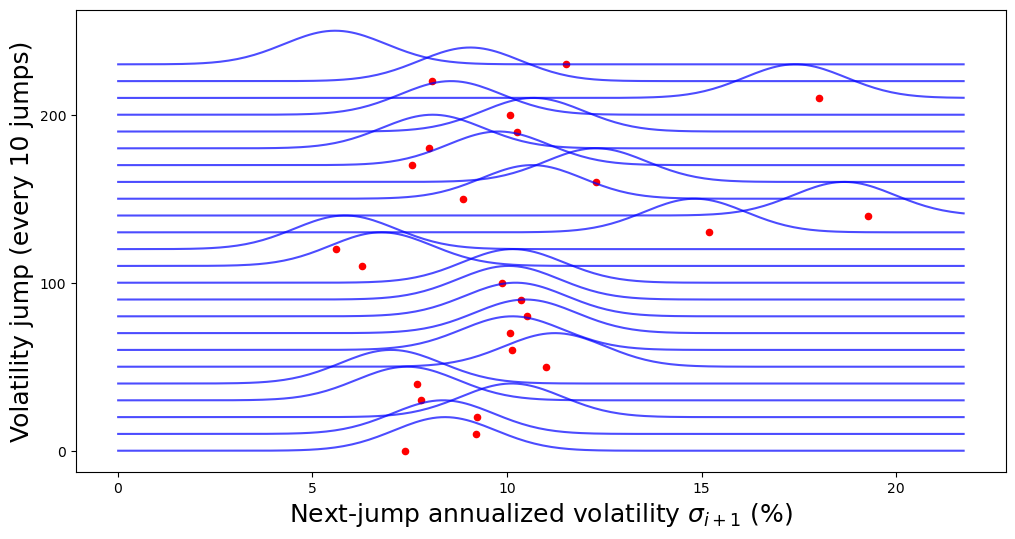

OU Log-Likelihood: 2.9189630437172966
OU RMSE: 0.013063918252179736


In [5]:
# OU model
sigma_vals = np.linspace(0.0001, (12/11)*np.max(sigma_real), 200)
plt.figure(figsize=(12,6))

step = 10
vertical_shift = 0.05

logL = 0
sq_errors = []

for i in range(len(sigma_real)-1):

    sigma_n = sigma_real[i]
    sigma_next = sigma_real[i+1]

    #Include the log-likelihood computtion for each step, and we will average it at the end to get a more interpretable metric
    pdf_val = f_OU(sigma_next, sigma_n, m_ou, k_ou, alpha_ou, t=1, t_0=0)
    logL += np.log(pdf_val + 1e-12)

    #Include the RMSE
    sigma_pred = m_ou + (sigma_n - m_ou)*np.exp(-alpha_ou)
    sq_errors.append((sigma_next - sigma_pred)**2)

    #Graphic validation of the kernel model by plotting the transition kernel and the actual next-step volatility
    if i % step == 0: # only plotting volatility after every 10 steps to avoid overcrowding the plot

        pdf = f_OU(sigma_vals, sigma_n, m_ou, k_ou, alpha_ou, t=1, t_0=0)
        pdf /= pdf.max()

        plt.plot(sigma_vals*100, pdf + i*vertical_shift, color='blue', alpha=0.7)
        plt.scatter(sigma_next*100, i*vertical_shift, color='red', s=20)
        plt.yticks([i*vertical_shift for i in range(0, len(sigma_real)-1, step*10)],[str(i) for i in range(0, len(sigma_real)-1, step*10)])

plt.xlabel("Next-jump annualized volatility $\\sigma_{i+1}$ (%)", fontsize=18)
plt.ylabel(f"Volatility jump (every {step} jumps)", fontsize=18)
plt.savefig("ou_transition_pdf.png", dpi=300)
plt.show()

# Print the metrics
avg_logL = logL/(len(sq_errors))
rmse = np.sqrt(np.mean(sq_errors))

print("OU Log-Likelihood:", avg_logL)
print("OU RMSE:", rmse)


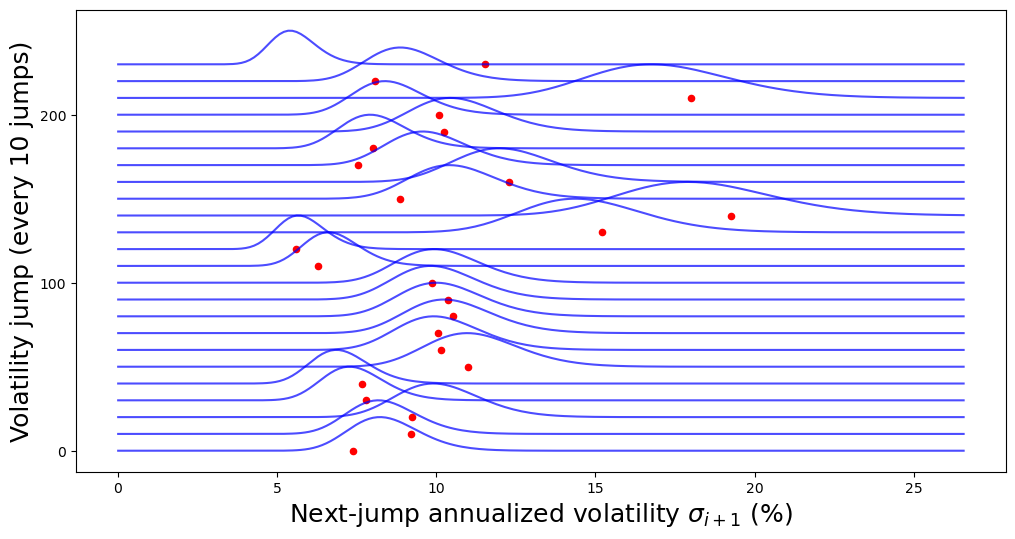

expOU Log-Likelihood: 2.9238923194068533
expOU RMSE: 0.01316963676151271


In [ ]:
# expOU model
sigma_vals = np.linspace(0.0001, (4/3)*np.max(sigma_real), 200)
plt.figure(figsize=(12,6))

step = 10
vertical_shift = 0.05

logL_expou = 0
sq_errors_expou = []

for i in range(len(sigma_real)-1): 
    sigma_n    = sigma_real[i]
    sigma_next = sigma_real[i+1]

    # Log-likelihood and RMSE at every step
    pdf_val = f_expOU(sigma_next, sigma_n, m_expou, k_expou, alpha_expou, t=1, t_0=0)
    logL_expou += np.log(pdf_val + 1e-12)

    sigma_pred = np.exp(m_expou + (np.log(sigma_n) - m_expou)*np.exp(-alpha_expou))
    sq_errors_expou.append((sigma_next - sigma_pred)**2)

    # Only plot every step points
    if i % step == 0:
        pdf = f_expOU(sigma_vals, sigma_n, m_expou, k_expou, alpha_expou, t=1, t_0=0)
        pdf /= pdf.max()
        plt.plot(sigma_vals*100, pdf + i*vertical_shift, color='blue', alpha=0.7)
        plt.scatter(sigma_next*100, i*vertical_shift, color='red', s=20)
        plt.yticks([i*vertical_shift for i in range(0, len(sigma_real)-1, step*10)],[str(i) for i in range(0, len(sigma_real)-1, step*10)])


avg_logL_expou = logL_expou / (len(sq_errors_expou))
rmse_expou = np.sqrt(np.mean(sq_errors_expou))

plt.xlabel("Next-jump annualized volatility $\\sigma_{i+1}$ (%)", fontsize=18)
plt.ylabel(f"Volatility jump (every {step} jumps)", fontsize=18)
plt.savefig("expou_transition_pdf.png", dpi=300)
plt.show()

print("expOU Log-Likelihood:", avg_logL_expou)
print("expOU RMSE:", rmse_expou)

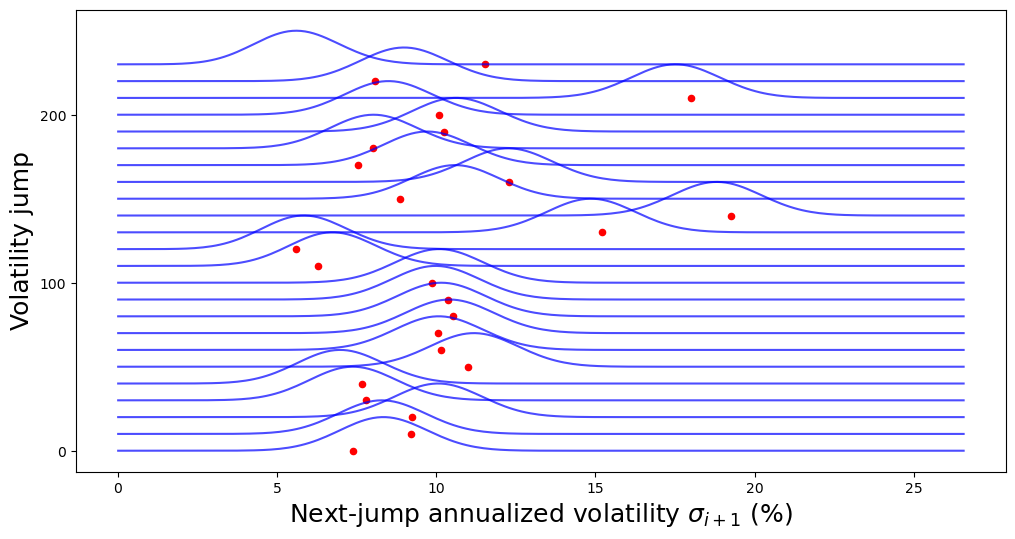

Heston Log-Likelihood: 2.920411052959986
Heston RMSE: 0.013059706340011745


In [ ]:
#heston model
sigma_vals = np.linspace(0.0001, (4/3)*np.max(sigma_real), 200)
plt.figure(figsize=(12, 6))

step = 10
vertical_shift = 0.05

logL_heston = 0
sq_errors_heston = []

for i in range(len(sigma_real)-1):  
    sigma_n    = sigma_real[i]
    sigma_next = sigma_real[i+1]

    # Log-likelihood, computed at every step
    pdf_val = f_heston(sigma_next, sigma_n, kappa, theta, delta, t=1, t_0=0)
    logL_heston += np.log(pdf_val + 1e-12)

    # RMSE, computed at every step
    v_pred = theta + (sigma_n**2 - theta) * np.exp(-kappa)
    sigma_pred = np.sqrt(np.abs(v_pred))
    sq_errors_heston.append((sigma_next - sigma_pred)**2)

    # Plot only every step points to avoid overcrowding
    if i % step == 0: 
        pdf = f_heston(sigma_vals, sigma_n, kappa, theta, delta, t=1, t_0=0)
        pdf /= pdf.max()
        plt.plot(sigma_vals*100, pdf + i*vertical_shift, color='blue', alpha=0.7)
        plt.scatter(sigma_next*100, i*vertical_shift, color='red', s=20)
        plt.yticks([i*vertical_shift for i in range(0, len(sigma_real)-1, step*10)],[str(i) for i in range(0, len(sigma_real)-1, step*10)])

avg_logL_heston = logL_heston / (len(sq_errors_heston))
rmse_heston     = np.sqrt(np.mean(sq_errors_heston))

plt.xlabel("Next-jump annualized volatility $\\sigma_{i+1}$ (%)", fontsize=18)
plt.ylabel(f"Volatility jump", fontsize=18)
plt.savefig("heston_transition_pdf.png", dpi=300)
plt.show()

print("Heston Log-Likelihood:", avg_logL_heston)
print("Heston RMSE:", rmse_heston)
#caption:

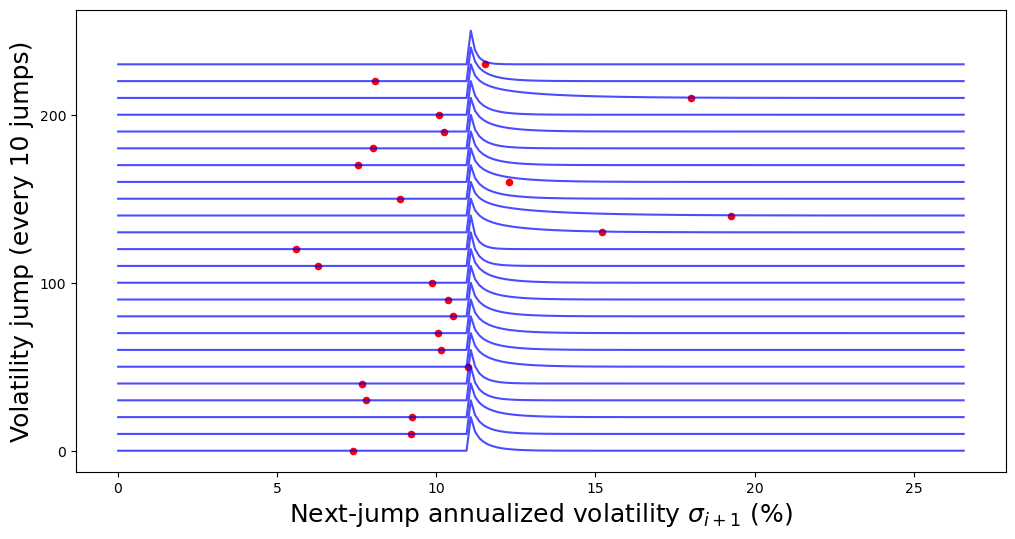

ARCH Log-Likelihood: -20.244110866954124
ARCH RMSE: 0.0356951803661369


In [8]:
# ARCH(1) model
sigma_vals = np.linspace(0.0001, (4/3)*np.max(sigma_real), 200)
plt.figure(figsize=(12,6))

logL_arch = 0
sq_errors_arch = []

step = 10  # only plot every 10th point
vertical_shift = 0.05  # space between kernel lines

for i in range(0, len(sigma_real)-1, step):
    sigma_n = sigma_real[i]
    sigma_next = sigma_real[i+1]

    # log-likelihood
    pdf_val = f_arch(sigma_next, sigma_n, alpha0, alpha1)
    logL_arch += np.log(pdf_val + 1e-12)

    # rmse
    sigma_pred = np.sqrt(alpha0 + alpha1*returns[i]**2)
    sq_errors_arch.append((sigma_next - sigma_pred)**2)

    if i % step == 0:
        pdf = f_arch(sigma_vals, sigma_n, alpha0, alpha1)
        pdf /= pdf.max()  # normalize for plotting
    
        plt.plot(sigma_vals*100, pdf + i*vertical_shift, color='blue', alpha=0.7)
        plt.scatter(sigma_next*100, i*vertical_shift, color='red', s=20)  # actual next-step volatility
        plt.yticks([i*vertical_shift for i in range(0, len(sigma_real)-1, step*10)],[str(i) for i in range(0, len(sigma_real)-1, step*10)])

plt.xlabel("Next-jump annualized volatility $\\sigma_{i+1}$ (%)", fontsize=18)
plt.ylabel(f"Volatility jump (every {step} jumps)", fontsize=18)
plt.savefig("arch_transition_pdf.png", dpi=300)
plt.show()

average_logL_arch = logL_arch / (len(sq_errors_arch))
rmse_arch = np.sqrt(np.mean(sq_errors_arch))

print("ARCH Log-Likelihood:", average_logL_arch)
print("ARCH RMSE:", rmse_arch)

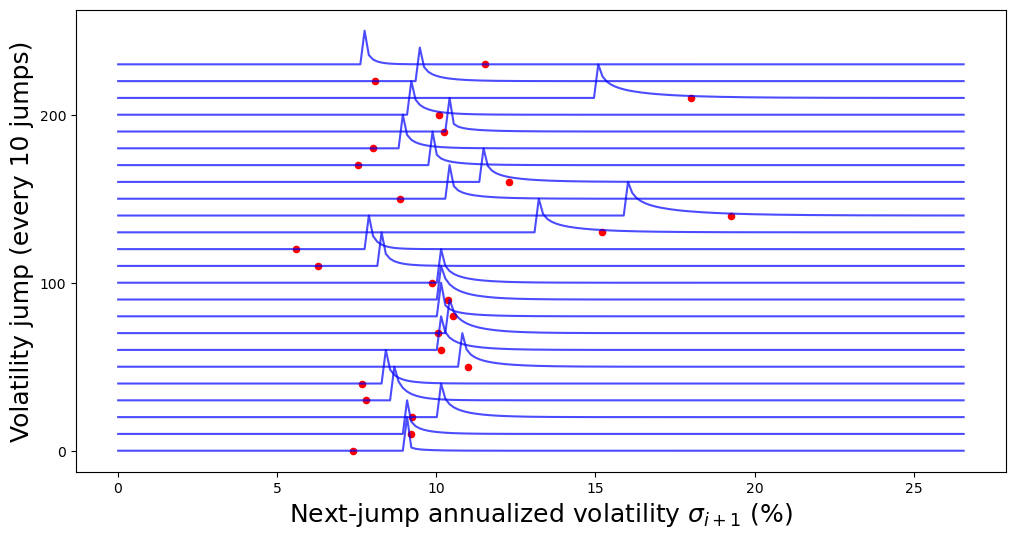

GARCH Log-Likelihood: -13.828972664050866
GARCH RMSE: 0.01961901040059757


In [9]:
# GARCH(1,1) model
sigma_vals = np.linspace(0.0001, (4/3)*np.max(sigma_real), 200)
plt.figure(figsize=(12,6))

logL_garch = 0
sq_errors_garch = []

step = 10  # only plot every 10th point
vertical_shift = 0.05  # space between kernel lines

for i in range(0, len(sigma_real)-1, step):
    sigma_n = sigma_real[i]
    sigma_next = sigma_real[i+1]

    # log-likelihood
    pdf_val = f_garch(sigma_next, sigma_n, omega, alpha, beta)
    logL_garch += np.log(pdf_val + 1e-12)

    # RMSE
    sigma_pred = np.sqrt(omega + alpha*returns[i]**2 + beta*sigma_n**2)
    sq_errors_garch.append((sigma_next - sigma_pred)**2)

    if i % step == 0:
    
        pdf = f_garch(sigma_vals, sigma_n, omega, alpha, beta)
        pdf /= pdf.max()  # normalize for plotting
    
        plt.plot(sigma_vals*100, pdf + i*vertical_shift, color='blue', alpha=0.7)
        plt.scatter(sigma_next*100, i*vertical_shift, color='red', s=20)  # actual next-step volatility
        plt.yticks([i*vertical_shift for i in range(0, len(sigma_real)-1, step*10)],[str(i) for i in range(0, len(sigma_real)-1, step*10)])

plt.xlabel("Next-jump annualized volatility $\\sigma_{i+1}$ (%)", fontsize=18)
plt.ylabel(f"Volatility jump (every {step} jumps)", fontsize=18)
plt.savefig("garch_transition_pdf.png", dpi=300)
plt.show()

average_logL_garch = logL_garch / (len(sq_errors_garch))
rmse_garch = np.sqrt(np.mean(sq_errors_garch))
print("GARCH Log-Likelihood:", average_logL_garch)
print("GARCH RMSE:", rmse_garch)

#### Using Variance for Heston 

During the volatility analysis, we've seen that the pdf of the expOU model, for example, adapted its width while the Heston did not. This is justified as we are working in the $\sigma^2$ space, while Heston works naturaly with variance. Due to this change, a Jacobian is introduced, therefore the variance:
$$\text{Var}(\sigma_{t+dt}|\sigma_{t})=(\frac{1}{2\sigma})^2 \text{Var}(v_{t+dt}|v_{t}).$$
In the variance space:
$$\text{Var}(v_{t+dt}|v_{t}) = \delta^2 v dt \sim v,$$
which explains why the width of the distribution adapts to the $v$ value. But in the volatility space:
$$\text{Var}(\sigma_{t+dt}|\sigma_{t})=\frac{\delta^2}{4}dt \sim ctt,$$
forcing the variance to be fixed independently of $\sigma$ value.


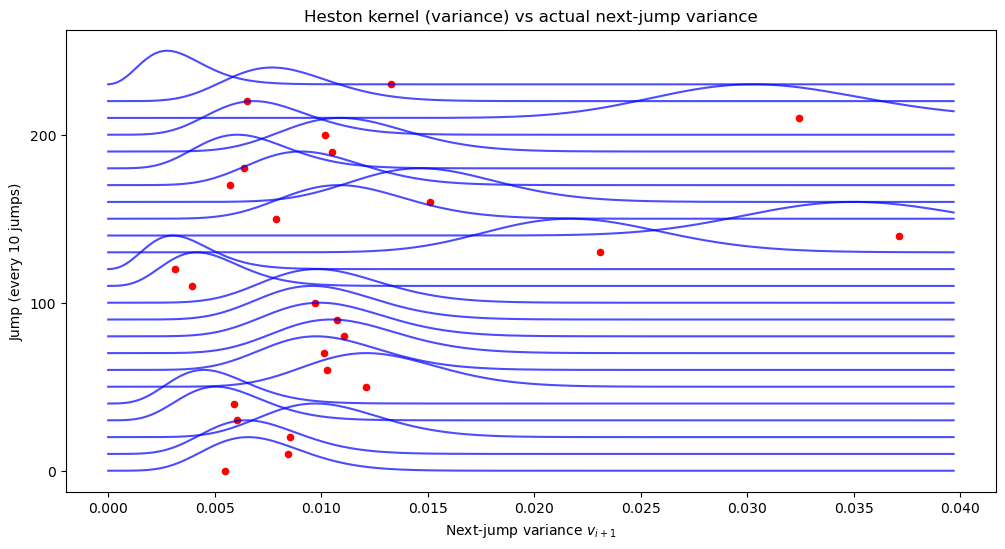

Heston Log-Likelihood: 4.203189632486193
Heston RMSE: 0.0031246166883143922


In [10]:
def f_heston_v(v, v0, kappa, theta, delta, t=1, t_0=0):
    dt = t - t_0

    c  = (delta**2 * (1 - np.exp(-kappa*dt))) / (4*kappa)
    nu = (2 * kappa * theta) / (delta**2)

    z = np.sqrt(v * v0 * np.exp(-kappa*dt)) / c

    f = (1 / (2*c)) \
        * np.exp(-(v + v0 * np.exp(-kappa*dt)) / (2*c) + z) \
        * (v / (v0 * np.exp(-kappa*dt)))**((nu/2) - 0.5) \
        * scipy.special.ive(nu - 1, 2*z)

    return np.where(np.isfinite(f), f, 0.0)

v_real = sigma_real**2
v_vals = np.linspace(1e-8, (2*np.max(sigma_real/2))**2, 200)

plt.figure(figsize=(12, 6))

step = 10
vertical_shift = 0.05

logL_heston = 0
sq_errors_heston = []

for i in range(len(v_real)-1):

    v_n    = v_real[i]
    v_next = v_real[i+1]

    # Likelihood
    pdf_val = f_heston_v(v_next, v_n, kappa, theta, delta)
    logL_heston += np.log(pdf_val + 1e-12)

    # Prediction (mean of CIR)
    v_pred = theta + (v_n - theta) * np.exp(-kappa)
    sq_errors_heston.append((v_next - v_pred)**2)

    # Plot
    if i % step == 0:
        pdf = f_heston_v(v_vals, v_n, kappa, theta, delta)
        pdf /= pdf.max()

        plt.plot(v_vals, pdf + i*vertical_shift, color='blue', alpha=0.7)
        plt.scatter(v_next, i*vertical_shift, color='red', s=20)

        plt.yticks(
            [i*vertical_shift for i in range(0, len(v_real)-1, step*10)],
            [str(i) for i in range(0, len(v_real)-1, step*10)]
        )

avg_logL_heston = logL_heston / len(sq_errors_heston)
rmse_heston     = np.sqrt(np.mean(sq_errors_heston))

plt.xlabel("Next-jump variance $v_{i+1}$")
plt.ylabel(f"Jump (every {step} jumps)")
plt.title("Heston kernel (variance) vs actual next-jump variance")
plt.show()

print("Heston Log-Likelihood:", avg_logL_heston)
print("Heston RMSE:", rmse_heston)